In [19]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report


seq_len = 30*4
overlap = 0.5
stride = int(seq_len * (1 - overlap))

# データ読み込み関数
def load_session(user="U0101", session="S0100", base_dir="../openpack_subset"):
    def load_atr(sensor):
        path = f"{base_dir}/{user}/atr/{sensor}/{session}.csv"
        df = pd.read_csv(path)
        df["datetime"] = pd.to_datetime(df["unixtime"], unit="ms", utc=True).dt.tz_convert("Asia/Tokyo")
        return df

    # --- センサデータ ---
    df_r = load_atr("atr01")  # 右手
    df_l = load_atr("atr02")  # 左手

    # --- ラベルデータ（operation / action 両方）---
    op_dir = f"{base_dir}/{user}/annotation"
    df_op_lv1 = pd.read_csv(f"{op_dir}/openpack-operations/{session}.csv")  # Lv1
    df_op_lv2 = pd.read_csv(f"{op_dir}/openpack-actions/{session}.csv")     # Lv2

    for df in [df_op_lv1, df_op_lv2]:
        df["start"] = pd.to_datetime(df["start"], format="mixed").dt.tz_convert("Asia/Tokyo")
        df["end"]   = pd.to_datetime(df["end"], format="mixed").dt.tz_convert("Asia/Tokyo")

    return df_r, df_l, df_op_lv1, df_op_lv2





# ウィンドウ分割
def window_split(df_r, df_l, df_op_lv1, df_op_lv2, window_size=256, stride=128):
    df_r = df_r.sort_values("unixtime")
    df_l = df_l.sort_values("unixtime")

    df = pd.merge_asof(
        df_r, df_l,
        on="unixtime",
        suffixes=("_r", "_l"),
        tolerance=20,
        direction="nearest"
    )

    arr = df[[
        "acc_x_r","acc_y_r","acc_z_r","gyro_x_r","gyro_y_r","gyro_z_r",
        # "acc_x_l","acc_y_l","acc_z_l","gyro_x_l","gyro_y_l","gyro_z_l"
    ]].values
    unixtime = df["unixtime"].values

    windows, labels_lv1, labels_lv2 = [], [], []

    for start in range(0, len(arr) - window_size, stride):
        end = start + window_size
        win = arr[start:end].T
        t_ts = pd.to_datetime(unixtime[start + window_size//2], unit="ms", utc=True).tz_convert("Asia/Tokyo")

        # --- Lv1: Operation ---
        op1 = df_op_lv1[(df_op_lv1["start"] <= t_ts) & (t_ts <= df_op_lv1["end"])]
        label_lv1 = op1["operation"].values[0] if len(op1) > 0 else "None"

        # --- Lv2: Action ---
        op2 = df_op_lv2[(df_op_lv2["start"] <= t_ts) & (t_ts <= df_op_lv2["end"])]
        label_lv2 = op2["action"].values[0] if len(op2) > 0 else "None"

        windows.append(win)
        labels_lv1.append(label_lv1)
        labels_lv2.append(label_lv2)

    return np.array(windows), np.array(labels_lv1), np.array(labels_lv2)



# Dataset 定義
class IMUDataset(Dataset):
    def __init__(self, X, y, yy):
        self.X = torch.tensor(X, dtype=torch.float32) # (B, 12, 256)
        self.y = torch.tensor(y, dtype=torch.long)
        self.yy = torch.tensor(yy, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i], self.yy[i]



In [20]:
from torch.utils.data import random_split
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    pretrain: bool            # SimCLR pretrain
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str           # directory to save results
    seed: int = 0             # random seed

def build_loaders_for_subject(test_user, users, sessions,
                              window_size=30*4*10,
                              stride_train=30*4*2,
                              stride_test=30*4*1,
                              valid_ratio=0.1,
                              batch_size=32,
                              config: ExperimentConfig = None):
    
    if config.model_type == "cnn-linear":
        window_size = 120 * 4
        train_stride = 60 * 1
        test_stride = 120 * 1
    elif config.model_type == "multi-trans":
        window_size = 120 * 10
        train_stride = 120 * 4
        test_stride = 120 * 1

    X_train, y_train, yy_train = [], [], []
    X_test,  y_test,  yy_test  = [], [], []

    # --- ユーザごとに読み込む ---
    for user in users:
        for sess in sessions:
            df_r, df_l, df_op, df_act = load_session(user, sess)

            # テストユーザ
            if user == test_user:
                X, y, yy = window_split(df_r, df_l, df_op,df_act,
                                    window_size=window_size,
                                    stride=test_stride)
                valid = (y != "None")
                X_test.append(X[valid])
                y_test.append(y[valid])
                yy_test.append(yy[valid])

            # 学習ユーザ
            else:
                X, y, yy = window_split(df_r, df_l, df_op,df_act,
                                    window_size=window_size,
                                    stride=train_stride)
                valid = (y != "None")
                X_train.append(X[valid])
                y_train.append(y[valid])
                yy_train.append(yy[valid])

    # --- 結合 ---
    X_train = np.concatenate(X_train)
    y_train = np.concatenate(y_train)
    yy_train = np.concatenate(yy_train)
    X_test  = np.concatenate(X_test)
    y_test  = np.concatenate(y_test)
    yy_test = np.concatenate(yy_test)

    # label encoding
    le = LabelEncoder()
    le.fit(np.unique(np.concatenate([y_train, y_test])))
    y_train_enc = le.transform(y_train)
    y_test_enc  = le.transform(y_test)

    le.fit(np.unique(np.concatenate([yy_train, yy_test])))
    yy_train_enc = le.transform(yy_train)
    yy_test_enc  = le.transform(yy_test) 

    # --- Dataset ---
    train_dataset = IMUDataset(X_train, y_train_enc, yy_train_enc)
    test_dataset  = IMUDataset(X_test,  y_test_enc, yy_test_enc)
    # --- train/valid split ---
    train_len = int(len(train_dataset) * (1 - valid_ratio))
    valid_len = len(train_dataset) - train_len
    train_ds, valid_ds = random_split(
        train_dataset,
        [train_len, valid_len],
        generator=torch.Generator().manual_seed(config.seed)
    )

    # --- DataLoader ---
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"[test_user={test_user}] Train={len(train_ds)}, Valid={len(valid_ds)}, Test={len(test_dataset)}")

    return train_loader, valid_loader, test_loader


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
import os
import json


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def compute_class_weights(train_loader, num_classes):
    counts = torch.zeros(num_classes)

    for _, labels, _ in train_loader:
        for c in range(num_classes):
            counts[c] += (labels == c).sum()

    total = counts.sum()
    counts[counts == 0] = 1  # 0割回避
    weights = total / (num_classes * counts)
    
    return weights                                                                                                                                                                                                                                                                               


# Train one epoch
def train_one_epoch(classifier, loader, optimizer, criterion):
    classifier.train()
    total_loss = 0
    total_n = 0

    for signals, labels, _ in loader:
        signals = signals.to(device)
        labels  = labels.to(device)

        logits, _, _ = classifier(signals)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        total_n    += len(labels)

    return total_loss / total_n



# Evaluate
def evaluate(classifier, loader, criterion=None):
    classifier.eval()
    total_loss = 0
    total_n = 0

    Y, P = [], []

    with torch.no_grad():
        for signals, labels, _ in loader:
            signals = signals.to(device)
            labels  = labels.to(device)

            logits, _ , _ = classifier(signals)
            preds  = logits.argmax(dim=1)

            Y.extend(labels.cpu().numpy())
            P.extend(preds.cpu().numpy())

            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * len(labels)
                total_n    += len(labels)

    if criterion is None:
        return Y, P, None
    else:
        return Y, P, total_loss / total_n

def record_results(test_user, y_true, y_pred,
                           results_dir="results_loso"):
    os.makedirs(results_dir, exist_ok=True)
    save_path = os.path.join(results_dir, f"{test_user}.json")

    result = {
        "user": test_user,
        "y_true": list(map(int, y_true)),
        "y_pred": list(map(int, y_pred))
    }
    with open(save_path, "w") as f:
        json.dump(result, f, indent=2)

    print(f"Saved: {save_path}")


In [22]:
import importlib
import models
importlib.reload(models)
from models import SimCLR, CNN_Encoder, TaskClassifier_Transformer, TaskClassifier_LSTM, TaskClassifier_Linear
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    pretrain: bool            # SimCLR pretrain
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str             # directory to save results
    seed: int = 0             # random seed

def build_model(config: ExperimentConfig):
    """
    config.model_type : "cnn-linear" or "multi-trans"
    config.pretrain   : True/False
    config.frozen     : True/False
    """

    # --- 1. Encoder 作成 ---
    if config.pretrain:
        sim = SimCLR(input_dim=6,seq_len=120,hidden_dim=64,feature_dim=128,projection_dim=64,dropout=0.3)
        sim.load_state_dict(torch.load(
            "/home/kisho_ucl/kisho_ws/har_warehouse/model/encoder_100_120w_1112.pth",
            map_location="cpu"
        ))
        encoder = sim.encoder
        print("Loaded pretrained encoder.")
    else:
        encoder = CNN_Encoder(input_dim=6, seq_len=120, hidden_dim=64, feature_dim=128, dropout=0.3)
        print("Created new encoder.")

    # --- Freeze設定 ---
    if config.frozen:
        for p in encoder.parameters():
            p.requires_grad = False

        print("Encoder is frozen.")
    else:
        print("Encoder is trainable.")

    # --- 2. Model selection ---
    if config.model_type == "cnn-linear":
        model = TaskClassifier_Linear(   # ← linear head なら別クラスでもOK
            encoder=encoder,
            feature_dim=128,
            hidden_dim=64,
            num_classes=11,
            dropout=0.1,
            freeze_encoder=config.frozen
        )
        return model

    elif config.model_type == "multi-trans":
        model = TaskClassifier_Transformer(
            encoder=encoder,
            feature_dim=128,
            window_len=120,
            overlap=0.5,
            num_heads=4,
            num_layers=3,
            num_classes=11,
            freeze_encoder=config.frozen
        )
        return model

    else:
        raise ValueError(f"Unknown model_type: {config.model_type}")
    
def build_optimizer(model, config: ExperimentConfig):

    # =============================
    # 1. encoder を固定する場合
    # =============================
    if config.frozen:
        print("Optimizer: frozen encoder → uniform LR 1e-4")
        params = [p for p in model.parameters() if p.requires_grad]
        return torch.optim.Adam(params, lr=1e-4)


    # =============================
    # 2. uniform LR
    # =============================
    if config.lr_type == "uniform":
        print("Optimizer: uniform lr=1e-4")
        return torch.optim.Adam(model.parameters(), lr=1e-4)


    # =============================
    # 3. layer-wise LR
    # =============================
    elif config.lr_type == "layerwise":

        encoder_lr = 1e-5
        head_lr = 1e-4

        if isinstance(model, TaskClassifier_Transformer):
            print("Optimizer: layerwise (Transformer)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.transformer.parameters(),  "lr": head_lr}, #out weight decay
                {"params": model.classifier.parameters(),   "lr": head_lr},
            ])

        elif isinstance(model, TaskClassifier_LSTM):
            print("Optimizer: layerwise (LSTM)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.lstm.parameters(),         "lr": head_lr}, # out weight decay
                {"params": model.classifier.parameters(),   "lr": head_lr},
            ])
        elif isinstance(model, TaskClassifier_Linear):
            print("Optimizer: layerwise (Linear)")
            return torch.optim.Adam([
                {"params": model.encoder.parameters(),      "lr": encoder_lr},
                {"params": model.classifier.parameters(),   "lr": head_lr}, # out weight decay
            ])
        else:
            raise ValueError("Unknown model architecture for layerwise LR")

    else:
        raise ValueError(f"Unknown lr_type {config.lr_type}")




In [23]:
from copy import deepcopy
import os
import json


class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False
        self.best_state = None
        self.best_epoch = 0

    def __call__(self, epoch, val_loss, model):
        # 初回、または改善したとき
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.best_state = deepcopy(model.state_dict())
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True



In [24]:
import models
importlib.reload(models)
from models import SimCLR, CNN_Encoder, TaskClassifier_Transformer, TaskClassifier_LSTM
from dataclasses import dataclass
import random

@dataclass
class ExperimentConfig:
    model_type: str           # "cnn-linear", "multi-trans"
    pretrain: bool            # SimCLR pretrain
    frozen: bool              # freeze encoder
    lr_type: str              # "uniform" or "layerwise" or "none" (when frozen)
    base_dir: str             # base directory to save results
    save_dir: str           # directory to save results
    seed: int = 0             # random seed

# Reset random seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# LOSO
def run_loso_one(
        train_loader, valid_loader, test_loader,
        weight_tensor, test_user="UNKNOWN",
        max_epochs=30, patience=5,
        config: ExperimentConfig = None):

    # Set random seed
    set_seed(config.seed)

    # モデル構築
    classifier = build_model(config).to(device)
    optimizer = build_optimizer(classifier, config)

    weight_tensor = weight_tensor.to(device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)


    # Early stopping
    early_stopper = EarlyStopping(patience=patience)

    # Training loop
    for epoch in range(1, max_epochs + 1):

        train_loss = train_one_epoch(classifier, train_loader, optimizer, criterion)
        _, _, valid_loss = evaluate(classifier, valid_loader, criterion)
        Y_tmp, P_tmp, test_loss = evaluate(classifier, test_loader, criterion)
        f1_tmp = f1_score(Y_tmp, P_tmp, average="weighted")

        print(
            f"[Epoch {epoch}/{max_epochs}] "
            f"Train={train_loss:.4f} | "
            f"Valid={valid_loss:.4f} | "
            f"Test={test_loss:.4f} | F1={f1_tmp:.4f}"
        )

        # early stopping check
        early_stopper(epoch, valid_loss, classifier)
        if early_stopper.early_stop:
            print("Early stopping.")
            break

    # Load best model
    classifier.load_state_dict(early_stopper.best_state)

    Y, P, _ = evaluate(classifier, test_loader, criterion)
    final_f1 = f1_score(Y, P, average="weighted")

    print(f"[SAVE PATH] {config.save_dir}/{test_user}.json")


    print(f"[{test_user}] Final F1 = {final_f1:.4f} | BestEpoch={early_stopper.best_epoch}")

    record_results(test_user, Y, P, results_dir=config.save_dir)

    return final_f1, Y, P, classifier

In [25]:
# ==========================================
# 実験設定
# ==========================================

configs = [
    # ────────────── No Pretrain ──────────────
    ExperimentConfig("multi-trans", False, False, "uniform",   "T1_noPT_uniform", ""),
    ExperimentConfig("multi-trans", False, False, "layerwise", "T2_noPT_layerwise", ""),

    # ────────────── Pretrain + Frozen ──────────────
    ExperimentConfig("multi-trans", True,  True,  "none",      "T3_PT_frozen", ""), 
    # ────────────── Pretrain + Fine-tune ──────────────
    ExperimentConfig("multi-trans", True,  False, "uniform",   "T4_PT_ft_uniform", ""),
    ExperimentConfig("multi-trans", True,  False, "layerwise", "T5_PT_ft_layerwise", ""),

    # ────────────── No Pretrain ──────────────
    ExperimentConfig("cnn-linear", False, False, "uniform",   "T6_noPT_uniform", ""),
    ExperimentConfig("cnn-linear", False, False, "layerwise", "T7_noPT_layerwise", ""),
    # ────────────── Pretrain + Frozen ──────────────
    ExperimentConfig("cnn-linear", True,  True,  "none",      "T8_PT_frozen", ""),
    # ────────────── Pretrain + Fine-tune ──────────────
    ExperimentConfig("cnn-linear", True,  False, "uniform",   "T9_PT_ft_uniform", ""),
    ExperimentConfig("cnn-linear", True,  False, "layerwise", "T10_PT_ft_layerwise", ""),
]


seeds = [0, 1, 2, 3, 4]

# configs = [  ExperimentConfig("cnn-linear", True,  True,  "none",      "T8_PT_frozen", "")]
# seeds = [0]

users = ["U0101","U0102","U0103","U0104","U0105","U0106","U0107","U0108","U0109","U0110"]
sessions = ["S0100"]

num_classes = 11  # ← Operation Recognition 用


# ==========================================
# 実験ループ（SEED → CONFIG → LOSO）
# ==========================================
for seed in seeds:

    print(f"\n=========== SEED {seed} ===========")

    for cfg in configs:

        print("===================================")
        print(f" Variant: {cfg.base_dir}")
        print("===================================")

        # seed ＆ save_dir の設定
        cfg.seed = seed
        cfg.save_dir = f"results_loso/seed{seed}/{cfg.base_dir}"

        # --- LOSO: test_user を 1 名ずつ抜く ---
        for test_user in users:

            set_seed(seed)

            # ---- Loader 構築（置き換え点①）----
            train_loader, valid_loader, test_loader = build_loaders_for_subject(
                test_user=test_user,
                users=users,
                sessions=sessions,
                window_size=30*4*10,
                stride_train=30*4*2,
                stride_test=30*4*1,
                valid_ratio=0.1,
                batch_size=32,
                config=cfg
            )

            # ---- class weight（置き換え点②）----
            weight_tensor = compute_class_weights(train_loader, num_classes=num_classes)
            weight_tensor = weight_tensor.to(device)

            # ---- 1 被験者に対する LOSO 学習（置き換え点③）----
            f1, Y, P, classifier = run_loso_one(
                train_loader,
                valid_loader,
                test_loader,
                weight_tensor=weight_tensor,
                test_user=test_user,
                max_epochs=20,
                patience=5,
                config=cfg
            )

            print(f"  Seed={seed}, User={test_user}, F1={f1:.4f}")



=========== SEED 0 ===========
 Variant: T1_noPT_uniform
[test_user=U0101] Train=1199, Valid=134, Test=527
Created new encoder.
Encoder is trainable.
Optimizer: uniform lr=1e-4
[Epoch 1/20] Train=2.3816 | Valid=2.2970 | Test=2.4676 | F1=0.0993
[Epoch 2/20] Train=2.3036 | Valid=2.2307 | Test=2.4130 | F1=0.0977
[Epoch 3/20] Train=2.2420 | Valid=2.1372 | Test=2.3410 | F1=0.2608
[Epoch 4/20] Train=2.1044 | Valid=2.2191 | Test=2.3112 | F1=0.2411
[Epoch 5/20] Train=1.9334 | Valid=1.8523 | Test=2.0698 | F1=0.4174
[Epoch 6/20] Train=1.7308 | Valid=1.6022 | Test=1.9641 | F1=0.5571
[Epoch 7/20] Train=1.5177 | Valid=1.4665 | Test=1.9896 | F1=0.4265
[Epoch 8/20] Train=1.3298 | Valid=1.2187 | Test=1.8756 | F1=0.6111
[Epoch 9/20] Train=1.1637 | Valid=1.1456 | Test=1.6566 | F1=0.6401
[Epoch 10/20] Train=1.0128 | Valid=0.9115 | Test=1.5907 | F1=0.6971
[Epoch 11/20] Train=0.8843 | Valid=0.8094 | Test=1.5401 | F1=0.7059
[Epoch 12/20] Train=0.7750 | Valid=0.7531 | Test=1.4938 | F1=0.7232
[Epoch 13/20] T

In [33]:
import os, json, numpy as np
from sklearn.metrics import f1_score

def load_variant_scores(root="results_loso"):
    scores = {}  # {variant: [f1_seed0, f1_seed1, ...]}

    for seed in sorted(os.listdir(root)):
        seed_dir = os.path.join(root, seed)
        if not os.path.isdir(seed_dir): 
            continue

        for variant in sorted(os.listdir(seed_dir)):
            var_dir = os.path.join(seed_dir, variant)
            if not os.path.isdir(var_dir):
                continue

            # Score list init
            if variant not in scores:
                scores[variant] = []

            # 各被験者JSONをseed単位で統合してF1を1つ算出
            y_all, p_all = [], []
            for fname in sorted(os.listdir(var_dir)):
                if not fname.endswith(".json"): 
                    continue
                with open(os.path.join(var_dir, fname)) as fp:
                    r = json.load(fp)
                y_all += r["y_true"]
                p_all += r["y_pred"]

            if len(y_all)==0:
                scores[variant].append(None)
            else:
                f1w = f1_score(np.array(y_all), np.array(p_all), average="weighted")
                scores[variant].append(f1w)

    return scores

scores = load_variant_scores()

def summarize_scores(scores):
    summary = {}
    for variant, vals in scores.items():
        vs = [v for v in vals if v is not None]
        summary[variant] = {
            "mean_f1": np.nanmean(vs),
            "var_f1":  np.nanvar(vs),
            "num_seeds": len(vs)
        }
    return summary

summary = summarize_scores(scores)



In [3]:
import os, json, numpy as np
from sklearn.metrics import f1_score

# def load_variant_scores(root="results_loso"):
#     scores = {}  # {variant: [f1_seed0, f1_seed1, ...]}

#     for seed in sorted(os.listdir(root)):
#         seed_dir = os.path.join(root, seed)
#         if not os.path.isdir(seed_dir): 
#             continue

#         for variant in sorted(os.listdir(seed_dir)):
#             var_dir = os.path.join(seed_dir, variant)
#             if not os.path.isdir(var_dir):
#                 continue

#             # Score list init
#             if variant not in scores:
#                 scores[variant] = []

#             # 各被験者JSONをseed単位で統合してF1を1つ算出
#             y_all, p_all = [], []
#             for fname in sorted(os.listdir(var_dir)):
#                 if not fname.endswith(".json"): 
#                     continue
#                 with open(os.path.join(var_dir, fname)) as fp:
#                     r = json.load(fp)
#                 y_all += r["y_true"]
#                 p_all += r["y_pred"]

#             if len(y_all)==0:
#                 scores[variant].append(None)
#             else:
#                 f1w = f1_score(np.array(y_all), np.array(p_all), average="weighted")
#                 scores[variant].append(f1w)

#     return scores

def load_variant_scores_per_subject(root="results_loso"):
    """
    return:
        { variant: [seed0_mean_f1, seed1_mean_f1, ...] }
    """
    scores = {}

    for seed in sorted(os.listdir(root)):
        seed_dir = os.path.join(root, seed)
        if not os.path.isdir(seed_dir):
            continue

        print(f"Loading results from: {seed_dir}")

        for variant in sorted(os.listdir(seed_dir)):
            var_dir = os.path.join(seed_dir, variant)
            if not os.path.isdir(var_dir):
                continue

            # variant の seed 配列を作成
            if variant not in scores:
                scores[variant] = []

            per_subject_f1 = []  # ← ★ ここに被験者ごとのF1を入れる

            # ---- 各JSON（= 各 test subject） ----
            for fname in sorted(os.listdir(var_dir)):
                if not fname.endswith(".json"):
                    continue

                with open(os.path.join(var_dir, fname)) as fp:
                    r = json.load(fp)

                y = np.array(r["y_true"])
                p = np.array(r["y_pred"])

                #f1_u = f1_score(y, p, average="weighted")
                f1_u = f1_score(y, p, average="macro")
                per_subject_f1.append(f1_u)

            # ---- seed のスコアとして「被験者平均」を登録 ----
            if len(per_subject_f1) == 0:
                scores[variant].append(None)
            else:
                mean_f1 = float(np.mean(per_subject_f1))
                scores[variant].append(mean_f1)

    return scores

scores = load_variant_scores_per_subject(root="results_loso/1202")

def summarize_scores(scores):
    summary = {}
    for variant, vals in scores.items():
        vs = [v for v in vals if v is not None]
        summary[variant] = {
            "mean_f1": np.nanmean(vs),
            "std_f1":  np.nanstd(vs),
            "num_seeds": len(vs)
        }
    return summary

summary = summarize_scores(scores)



Loading results from: results_loso/1202/seed0
Loading results from: results_loso/1202/seed1
Loading results from: results_loso/1202/seed2
Loading results from: results_loso/1202/seed3
Loading results from: results_loso/1202/seed4


In [4]:
summary
order = [
    "T6_noPT_uniform",
    "T7_noPT_layerwise",
    "T8_PT_frozen",
    "T9_PT_ft_uniform",
    "T10_PT_ft_layerwise",

    "T6_noPT_uniform_smooth",
    "T7_noPT_layerwise_smooth",
    "T8_PT_frozen_smooth",
    "T9_PT_ft_uniform_smooth",
    "T10_PT_ft_layerwise_smooth",
    
    "T1_noPT_uniform",
    "T2_noPT_layerwise",
    "T3_PT_frozen",
    "T4_PT_ft_uniform",
    "T5_PT_ft_layerwise",
]

summary_ordered = {k: summary[k] for k in order}

| Variant | Mean(F1) | Std(F1) | #Seeds |
|---|---|---|---|
| T6_noPT_uniform | 0.599 | 0.012 | 5 |
| T7_noPT_layerwise | 0.508 | 0.012 | 5 |
| T8_PT_frozen | 0.594 | 0.004 | 5 |
| T9_PT_ft_uniform | 0.659 | 0.010 | 5 |
| T10_PT_ft_layerwise | 0.630 | 0.005 | 5 |
| T6_noPT_uniform_smooth | 0.505 | 0.007 | 5 |
| T7_noPT_layerwise_smooth | 0.437 | 0.012 | 5 |
| T8_PT_frozen_smooth | 0.496 | 0.005 | 5 |
| T9_PT_ft_uniform_smooth | 0.534 | 0.011 | 5 |
| T10_PT_ft_layerwise_smooth | 0.517 | 0.004 | 5 |
| T1_noPT_uniform | 0.646 | 0.031 | 5 |
| T2_noPT_layerwise | 0.551 | 0.030 | 5 |
| T3_PT_frozen | 0.758 | 0.019 | 5 |
| T4_PT_ft_uniform | 0.751 | 0.022 | 5 |
| T5_PT_ft_layerwise | 0.762 | 0.019 | 5 |



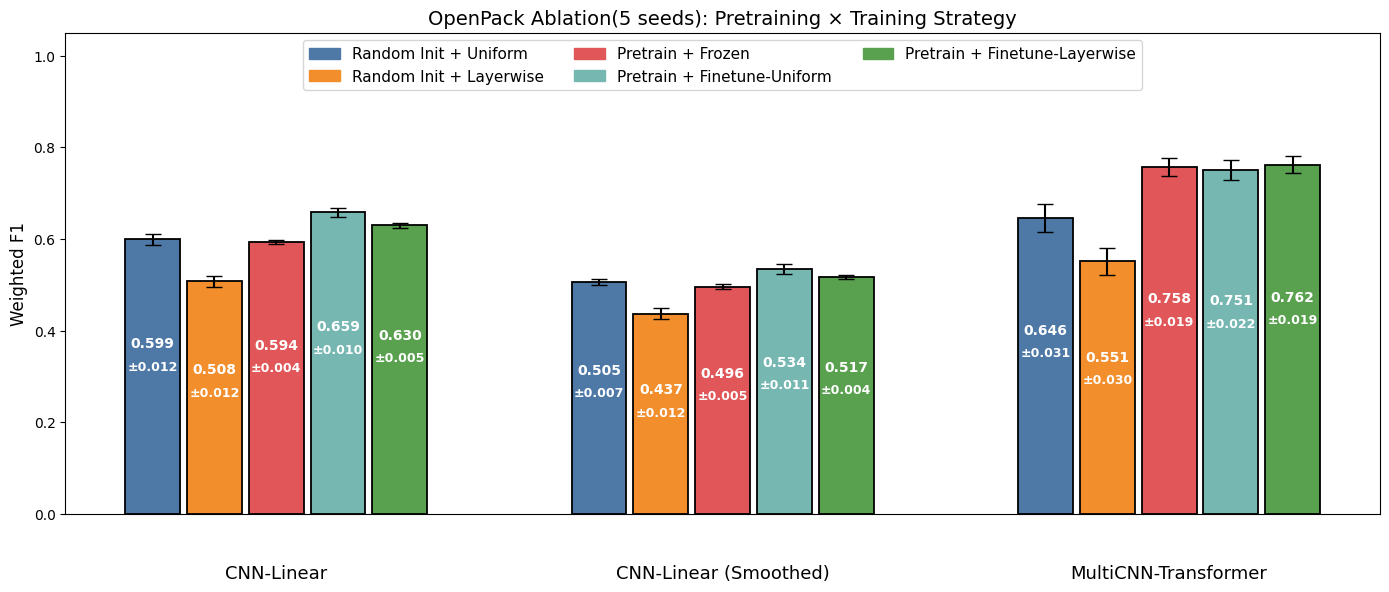

In [5]:
import pandas as pd
df = pd.DataFrame(
    [(k, v["mean_f1"], v["std_f1"], v["num_seeds"]) for k,v in summary_ordered.items()],
    columns=["variant","mean_f1","std_f1","num_seeds"]
)

md = "| Variant | Mean(F1) | Std(F1) | #Seeds |\n"
md+= "|---|---|---|---|\n"
for _,r in df.iterrows():
    md+= f"| {r.variant} | {r.mean_f1:.3f} | {r.std_f1:.3f} | {int(r.num_seeds)} |\n"
print(md)


# --- df (variant, mean_f1, std_f1, num_seeds) は既にある前提 ---

import matplotlib.pyplot as plt
import numpy as np

# カラーマップ（最大10）
colors10 = [
    "#4e79a7",  # blue
    "#f28e2c",  # orange
    "#76b7b2",  # green-ish
    "#e15759",  # red
    "#59a14f",  # green
    "#af7aa1",  # purple
    "#ff9da7",  # pink
    "#9c755f",  # brown
    "#bab0ac",  # gray
    "#edc948"   # yellow
]


# グループ定義
group_A = ["T6_noPT_uniform","T7_noPT_layerwise","T8_PT_frozen","T9_PT_ft_uniform","T10_PT_ft_layerwise"]
group_B = ["T6_noPT_uniform_smooth","T7_noPT_layerwise_smooth","T8_PT_frozen_smooth","T9_PT_ft_uniform_smooth","T10_PT_ft_layerwise_smooth"]
group_C = ["T1_noPT_uniform","T2_noPT_layerwise","T3_PT_frozen","T4_PT_ft_uniform","T5_PT_ft_layerwise"]

def label_group(v):
    if v in group_A:
        return "A"
    elif v in group_B:
        return "B"
    elif v in group_C:
        return "C"
    else:
        return "Unknown"

df["group"] = df["variant"].apply(label_group)

# A → B → C の順番で concat
df_sorted = pd.concat([
    df[df["group"]=="A"],
    df[df["group"]=="B"],
    df[df["group"]=="C"]
], axis=0).reset_index(drop=True)

import matplotlib.pyplot as plt
import numpy as np

# ====== 色設定：5種類 ======
colors5 = [
    "#4e79a7",  # 1: Random Init + Uniform
    "#f28e2c",  # 2: Random Init + Layerwise
    "#e15759",  # 3: Pretrain + Frozen
    "#76b7b2",  # 4: Pretrain + FT-Uniform
    "#59a14f",  # 5: Pretrain + FT-Layerwise
]

labels5 = [
    "Random Init + Uniform",
    "Random Init + Layerwise",
    "Pretrain + Frozen",
    "Pretrain + Finetune-Uniform",
    "Pretrain + Finetune-Layerwise",
]

# ====== df_sortedから値を取り出す ======
variants = df_sorted["variant"].tolist()
means    = df_sorted["mean_f1"].to_numpy()
stds     = df_sorted["std_f1"].to_numpy()
groups   = df_sorted["group"].tolist()


# ====== x座標：グループ間に隙間 ======
x = []
gap = 2.0   # ← A/B/C 間隔を広く
pos = 0

for i, g in enumerate(groups):
    # グループが変わる瞬間に gap
    if i > 0 and groups[i-1] != g:
        pos += gap
    x.append(pos)
    pos += 0.9  # グループ内は狭め


x = np.array(x)

# ====== グループ内インデックス（0〜4） ======
index_within_group = [(i % 5) for i in range(len(variants))]
bar_colors = [colors5[idx] for idx in index_within_group]


# ====== Plot ======
plt.figure(figsize=(14, 6))

plt.bar(
    x, means, yerr=stds,
    color=bar_colors,
    capsize=6,
    edgecolor="black",
    linewidth=1.3
)


# ====== バー内部に mean と std ======
for xi, m, s in zip(x, means, stds):
    plt.text(xi, m*0.62, f"{m:.3f}",
             ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    plt.text(xi, m*0.62 - 0.05, f"±{s:.3f}",
             ha="center", va="center", fontsize=9, fontweight="bold", color="white")


# ====== x軸ラベルは消す ======
plt.xticks([], [])
plt.ylabel("Weighted F1", fontsize=12)
plt.ylim(0, 1.05)


# ====== グループ中央位置の計算 ======

# A 群
idx_A = np.where(df_sorted["group"]=="A")[0]
mid_A = np.mean(x[idx_A])

# B 群
idx_B = np.where(df_sorted["group"]=="B")[0]
mid_B = np.mean(x[idx_B])

# C 群
idx_C = np.where(df_sorted["group"]=="C")[0]
mid_C = np.mean(x[idx_C])


# ====== グループ名を表示 ======
plt.text(mid_A, -0.14, "CNN-Linear", ha="center", fontsize=13)
plt.text(mid_B, -0.14, "CNN-Linear (Smoothed)", ha="center", fontsize=13)
plt.text(mid_C, -0.14, "MultiCNN-Transformer", ha="center", fontsize=13)


# ====== 凡例 ======
handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors5]
plt.legend(handles, labels5, ncol=3, fontsize=11, loc="upper center")

plt.title("OpenPack Ablation(5 seeds): Pretraining × Training Strategy", fontsize=14)
plt.tight_layout()
plt.show()



In [38]:
!ls results_loso/seed0

T10_PT_ft_layerwise  T3_PT_frozen	 T6_noPT_uniform    T9_PT_ft_uniform
T1_noPT_uniform      T4_PT_ft_uniform	 T7_noPT_layerwise
T2_noPT_layerwise    T5_PT_ft_layerwise  T8_PT_frozen


[Warning] Missing dir: results_loso/seed5/T1_noPT_uniform
=== Mean Weighted F1 per seed ===
seed0: 0.7206
seed1: 0.6456
seed2: 0.7239
seed3: 0.6966
seed4: 0.7204


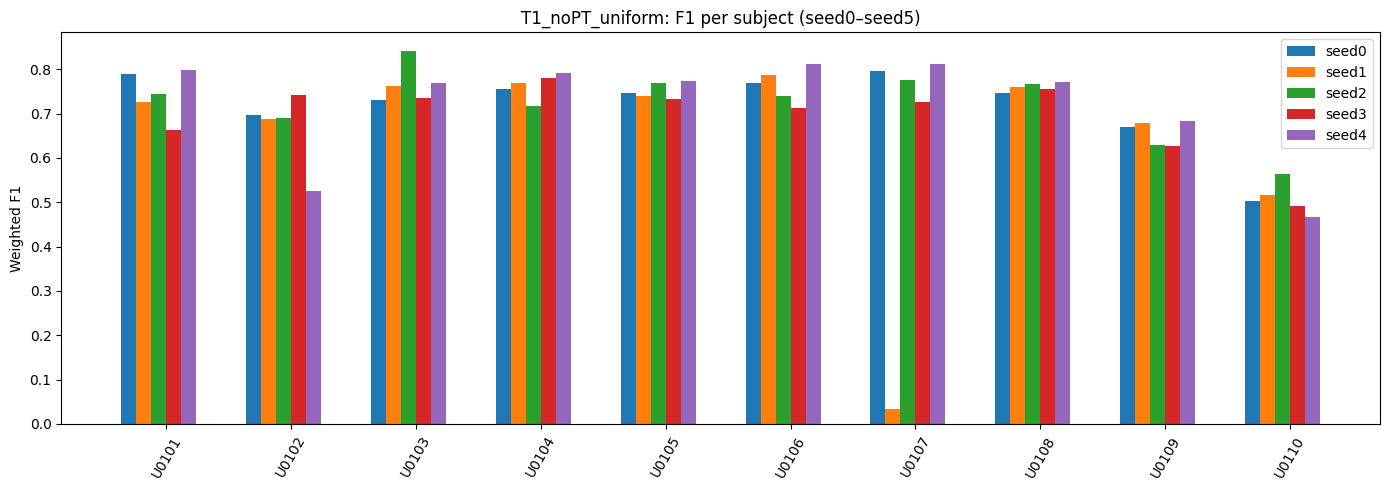

In [39]:
import os, json, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

def load_subject_f1_for_variant(root, variant, seeds=["seed0","seed1"]):
    """
    return:
        result[seed][subject] = weighted_f1
    """
    result = {}

    for seed in seeds:
        seed_dir = os.path.join(root, seed, variant)
        if not os.path.isdir(seed_dir):
            print(f"[Warning] Missing dir: {seed_dir}")
            continue

        result[seed] = {}

        for fname in sorted(os.listdir(seed_dir)):
            if not fname.endswith(".json"):
                continue

            subject = fname.replace(".json","")
            with open(os.path.join(seed_dir, fname)) as fp:
                r = json.load(fp)

            y = np.array(r["y_true"])
            p = np.array(r["y_pred"])

            f1w = f1_score(y, p, average="weighted")
            result[seed][subject] = f1w

    return result


# ==== 実行 ====
root = "results_loso"
variant = "T1_noPT_uniform"
seeds = [f"seed{i}" for i in range(6)] 

f1_dict = load_subject_f1_for_variant(root, variant, seeds=seeds)


print("=== Mean Weighted F1 per seed ===")
for seed in seeds:
    if seed not in f1_dict:
        continue
    vals = list(f1_dict[seed].values())
    mean_f1 = np.mean(vals)
    print(f"{seed}: {mean_f1:.4f}")


subjects = sorted(list(f1_dict[seeds[0]].keys()))
x = np.arange(len(subjects))
width = 0.12

plt.figure(figsize=(14,5))

for i, seed in enumerate(seeds):
    if seed not in f1_dict:
        continue
    plt.bar(x + width*(i-2.5),
            [f1_dict[seed][s] for s in subjects],
            width=width,
            label=seed)

plt.xticks(x, subjects, rotation=60)
plt.ylabel("Weighted F1")
plt.title(f"{variant}: F1 per subject (seed0–seed5)")
plt.legend()
plt.tight_layout()
plt.show()


[Warning] Missing dir: results_loso/seed5/T2_noPT_layerwise
=== Mean Weighted F1 per seed ===
seed0: 0.5935
seed1: 0.5448
seed2: 0.5939
seed3: 0.5885
seed4: 0.6220


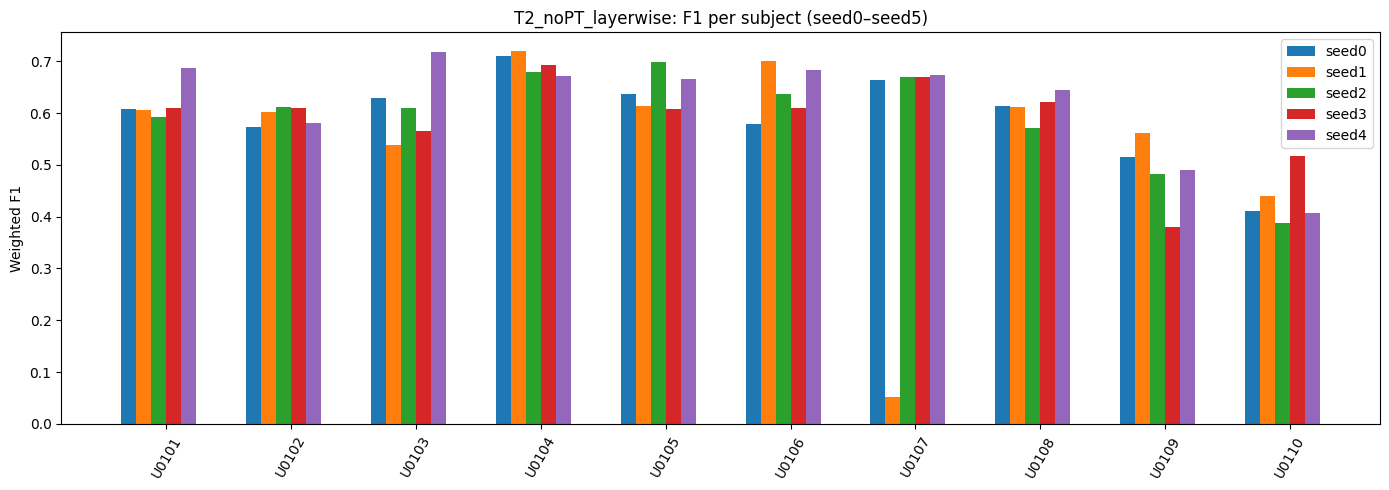

In [ ]:
root = "results_loso"
variant = "T2_noPT_layerwise"
seeds = [f"seed{i}" for i in range(6)] 

f1_dict = load_subject_f1_for_variant(root, variant, seeds=seeds)


print("=== Mean Weighted F1 per seed ===")
for seed in seeds:
    if seed not in f1_dict:
        continue
    vals = list(f1_dict[seed].values())
    mean_f1 = np.mean(vals)
    print(f"{seed}: {mean_f1:.4f}")


subjects = sorted(list(f1_dict[seeds[0]].keys()))
x = np.arange(len(subjects))
width = 0.12

plt.figure(figsize=(14,5))

for i, seed in enumerate(seeds):
    if seed not in f1_dict:
        continue
    plt.bar(x + width*(i-2.5),
            [f1_dict[seed][s] for s in subjects],
            width=width,
            label=seed)

plt.xticks(x, subjects, rotation=60)
plt.ylabel("Weighted F1")
plt.title(f"{variant}: F1 per subject (seed0–seed5)")
plt.legend()
plt.tight_layout()
plt.show()


[Warning] Missing dir: results_loso/seed5/T2_noPT_layerwise
=== Mean Weighted F1 per seed ===
seed0: 0.5935
seed1: 0.5448
seed2: 0.5939
seed3: 0.5885
seed4: 0.6220


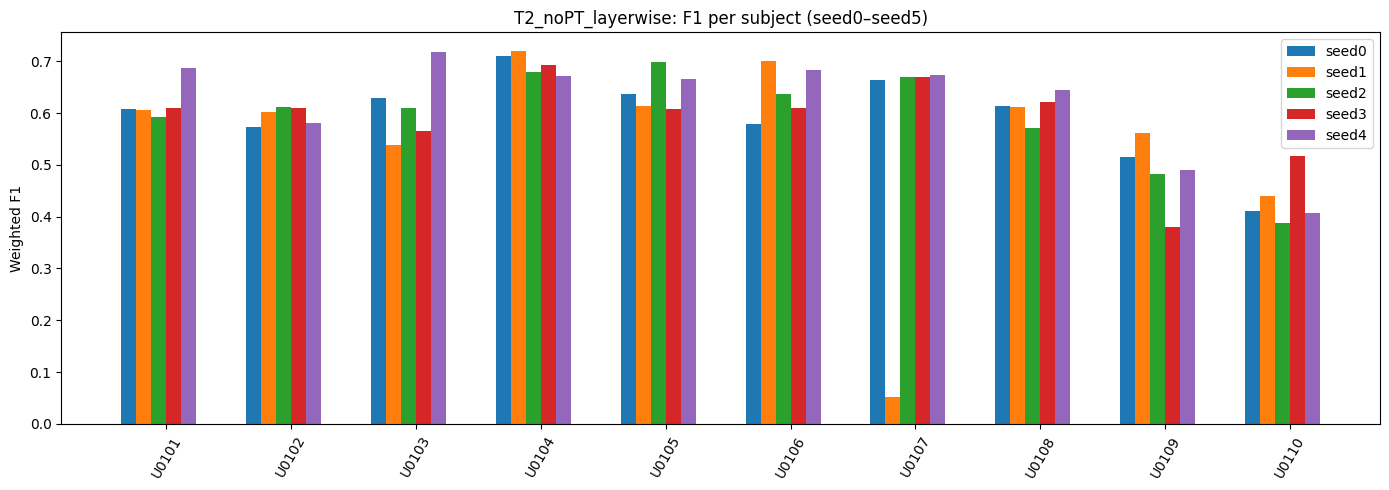

In [ ]:
root = "results_loso"
variant = "T2_noPT_layerwise"
seeds = [f"seed{i}" for i in range(6)] 

f1_dict = load_subject_f1_for_variant(root, variant, seeds=seeds)


print("=== Mean Weighted F1 per seed ===")
for seed in seeds:
    if seed not in f1_dict:
        continue
    vals = list(f1_dict[seed].values())
    mean_f1 = np.mean(vals)
    print(f"{seed}: {mean_f1:.4f}")


subjects = sorted(list(f1_dict[seeds[0]].keys()))
x = np.arange(len(subjects))
width = 0.12

plt.figure(figsize=(14,5))

for i, seed in enumerate(seeds):
    if seed not in f1_dict:
        continue
    plt.bar(x + width*(i-2.5),
            [f1_dict[seed][s] for s in subjects],
            width=width,
            label=seed)

plt.xticks(x, subjects, rotation=60)
plt.ylabel("Weighted F1")
plt.title(f"{variant}: F1 per subject (seed0–seed5)")
plt.legend()
plt.tight_layout()
plt.show()
